# **Part A — Data preparation**

In [1]:
import pandas as pd

In [2]:
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

In [3]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [4]:
print("\nMissing values (Sentiment):")
print(sentiment.isnull().sum())


Missing values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [5]:
print("\nMissing values (Trades):")
print(trades.isnull().sum())


Missing values (Trades):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
print("\nDuplicate rows Sentiment:", sentiment.duplicated().sum())
print("Duplicate rows Trades:", trades.duplicated().sum())


Duplicate rows Sentiment: 0
Duplicate rows Trades: 0


In [7]:
# Convert to datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# Create date column for trades
trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

In [8]:
print(trades['Timestamp IST'].head())

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]


In [9]:
print(sentiment['date'].head())

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]


In [10]:
merged = pd.merge(trades, sentiment, on='Date', how='left')

In [11]:
print(merged[['Date','classification']].head())
print(merged['classification'].value_counts())

         Date classification
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [12]:
# daily PnL per trader
daily_pnl = merged.groupby(['Account','Date'])['Closed PnL'].sum().reset_index()

In [13]:
daily_pnl.rename(columns={'Closed PnL': 'Daily_PnL'}, inplace=True)
print(daily_pnl.head())

                                      Account        Date  Daily_PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1


In [14]:
# win rate
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)
print(win_rate.head())

                                      Account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914


In [15]:
win_rate_sentiment = merged.groupby('classification')['win'].mean().reset_index()
print(win_rate_sentiment)

  classification       win
0   Extreme Fear  0.370607
1  Extreme Greed  0.464943
2           Fear  0.420768
3          Greed  0.384828
4        Neutral  0.396991


In [16]:
# average trade size
avg_size = merged.groupby('Account')['Size USD'].mean().reset_index()

In [17]:
trades_per_day = merged.groupby('Date').size().reset_index(name='num_trades')

In [18]:
# long/short ratio
long_short = merged.groupby(['Date','Side']).size().unstack().fillna(0)
long_short['Long_Short_Ratio'] = long_short['BUY'] / long_short['SELL']

In [19]:
fee_stats = merged['Fee'].describe()

In [20]:
pnl_volatility = daily_pnl.groupby('Account')['Daily_PnL'].std().reset_index()
pnl_volatility.rename(columns={'Daily_PnL':'PnL_Volatility'}, inplace=True)

In [21]:
daily_pnl_sentiment = pd.merge(daily_pnl, sentiment, on='Date', how='left')

In [22]:
drawdown_proxy_sentiment = daily_pnl_sentiment.groupby('classification')['Daily_PnL'].std().reset_index()
drawdown_proxy_sentiment.rename(columns={'Daily_PnL':'Drawdown_Proxy'}, inplace=True)

print(drawdown_proxy_sentiment)

  classification  Drawdown_Proxy
0   Extreme Fear    29534.839183
1  Extreme Greed    27496.863832
2           Fear    31659.771538
3          Greed    30599.040173
4        Neutral    17447.863645


In [23]:
max_loss_sentiment = daily_pnl_sentiment.groupby('classification')['Daily_PnL'].min().reset_index()
max_loss_sentiment.rename(columns={'Daily_PnL':'Max_Daily_Loss'}, inplace=True)

print(max_loss_sentiment)

  classification  Max_Daily_Loss
0   Extreme Fear   -77308.420095
1  Extreme Greed  -132271.000000
2           Fear  -108604.496278
3          Greed  -358963.139984
4        Neutral  -113601.020138


In [24]:
# Aggregated dataset
analysis_df = merged.groupby(['Date','classification']).agg({
    'Closed PnL':'sum',
    'Account':'nunique',
    'Size USD':'mean',
    'Trade ID':'count'
}).reset_index()

analysis_df.rename(columns={
    'Closed PnL':'Daily_Total_PnL',
    'Account':'Num_Traders',
    'Size USD':'Avg_Trade_Size',
    'Trade ID':'Num_Trades'
}, inplace=True)

print(analysis_df.head())

         Date classification  Daily_Total_PnL  Num_Traders  Avg_Trade_Size  \
0  2023-05-01          Greed         0.000000            1      159.000000   
1  2023-12-05  Extreme Greed         0.000000            1     5556.203333   
2  2023-12-14          Greed      -205.434737            1    10291.213636   
3  2023-12-15          Greed       -24.632034            1     5304.975000   
4  2023-12-16          Greed         0.000000            1     5116.256667   

   Num_Trades  
0           3  
1           9  
2          11  
3           2  
4           3  


In [25]:
# Profit per trader
analysis_df['PnL_per_Trader'] = analysis_df['Daily_Total_PnL'] / analysis_df['Num_Traders']
print(analysis_df.head())

         Date classification  Daily_Total_PnL  Num_Traders  Avg_Trade_Size  \
0  2023-05-01          Greed         0.000000            1      159.000000   
1  2023-12-05  Extreme Greed         0.000000            1     5556.203333   
2  2023-12-14          Greed      -205.434737            1    10291.213636   
3  2023-12-15          Greed       -24.632034            1     5304.975000   
4  2023-12-16          Greed         0.000000            1     5116.256667   

   Num_Trades  PnL_per_Trader  
0           3        0.000000  
1           9        0.000000  
2          11     -205.434737  
3           2      -24.632034  
4           3        0.000000  


In [26]:
summary_sentiment = analysis_df.groupby('classification').agg({
    'Daily_Total_PnL':'mean',
    'Num_Traders':'mean',
    'Avg_Trade_Size':'mean',
    'Num_Trades':'mean'
}).reset_index()

print(summary_sentiment)

  classification  Daily_Total_PnL  Num_Traders  Avg_Trade_Size   Num_Trades
0   Extreme Fear     52793.589178    11.428571     4091.804366  1528.571429
1  Extreme Greed     23817.292199     4.614035     4410.524482   350.807018
2           Fear     36891.818040     6.923077     6524.294937   679.527473
3          Greed     11140.566181     3.357513     6735.295813   260.637306
4        Neutral     19297.323516     5.611940     7157.527121   562.477612


# **Part B — Analysis**

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

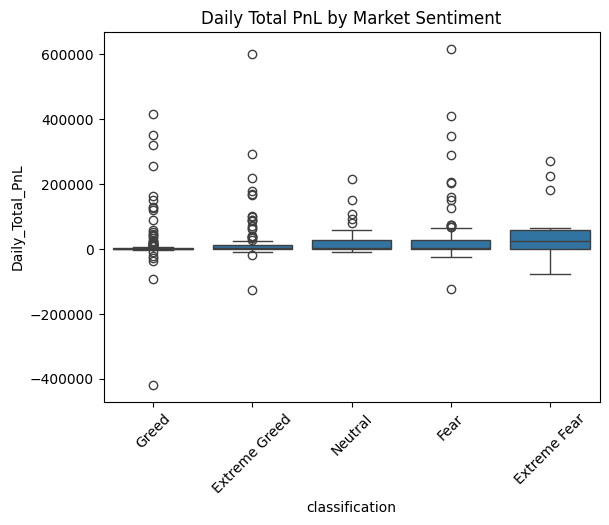

In [28]:
# Daily PnL by Sentiment
plt.figure()
sns.boxplot(x='classification', y='Daily_Total_PnL', data=analysis_df)
plt.title('Daily Total PnL by Market Sentiment')
plt.xticks(rotation=45)
plt.show()

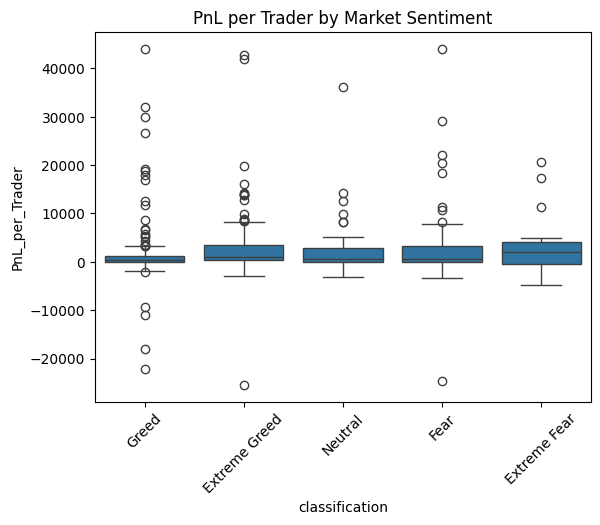

In [29]:
# PnL per trader
plt.figure()
sns.boxplot(x='classification', y='PnL_per_Trader', data=analysis_df)
plt.title('PnL per Trader by Market Sentiment')
plt.xticks(rotation=45)
plt.show()

*Trader profitability is higher during Fear and Extreme Fear market conditions compared to Greed periods. While Extreme Greed shows occasional large profits, the median profitability is lower and more volatile. This suggests that traders perform more consistently during Fear periods, possibly due to more cautious and disciplined trading behavior.*

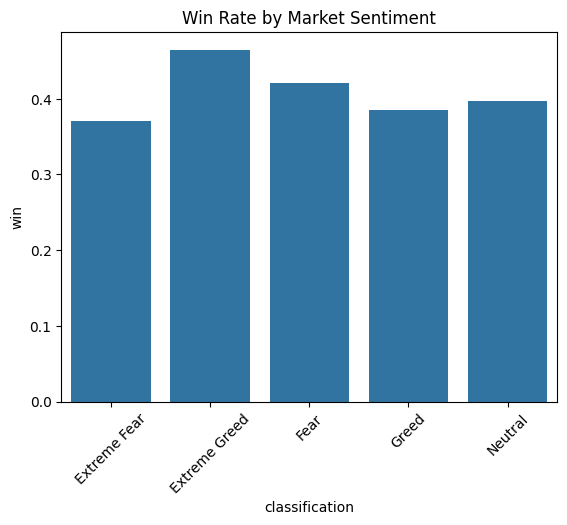

In [30]:
# Win rate by sentiment
plt.figure()
sns.barplot(x='classification', y='win', data=win_rate_sentiment)
plt.title('Win Rate by Market Sentiment')
plt.xticks(rotation=45)
plt.show()

*Win rates are highest during Extreme Greed periods; however, this does not translate into the highest profitability. This indicates that traders may be taking frequent small-profit trades during Greed periods but are exposed to occasional large losses, reducing overall profitability.*

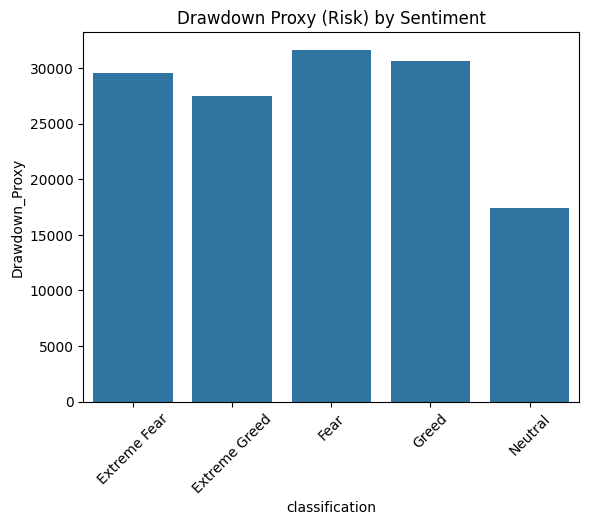

In [31]:
# Drawdown proxy by sentiment
plt.figure()
sns.barplot(x='classification', y='Drawdown_Proxy', data=drawdown_proxy_sentiment)
plt.title('Drawdown Proxy (Risk) by Sentiment')
plt.xticks(rotation=45)
plt.show()

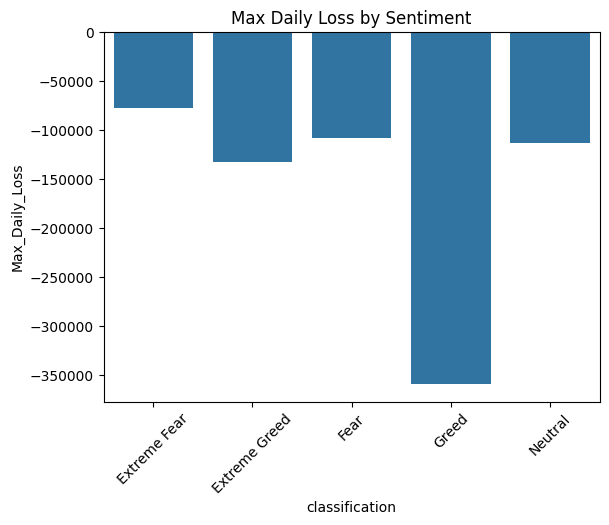

In [32]:
# Max Daily Loss by Sentiment
plt.figure()
sns.barplot(x='classification', y='Max_Daily_Loss', data=max_loss_sentiment)
plt.title('Max Daily Loss by Sentiment')
plt.xticks(rotation=45)
plt.show()

*Risk levels, measured using PnL volatility and maximum daily loss, vary across sentiment regimes. Although Fear periods show higher volatility, the largest single-day losses occur during Greed periods. This suggests that traders take excessive risk during Greed markets, leading to larger drawdowns despite lower overall profitability.*

***Thus we can conclude that, trader performance differs significantly between Fear and Greed market conditions. Fear and Extreme Fear periods are associated with higher median profitability and more consistent returns. In contrast, Greed and Extreme Greed periods show higher win rates but lower overall profitability and higher maximum losses, indicating riskier trading behavior. This suggests that traders tend to overtrade and take excessive risk during Greed periods, which reduces overall performance despite frequent winning trades.***

| Metric        | Fear   | Greed  |
| ------------- | ------ | ------ |
| Profitability | Higher | Lower  |
| Win Rate      | Medium | High   |
| Risk          | Medium | High   |
| Max Loss      | Lower  | Higher |
| Performance   | Better | Worse  |


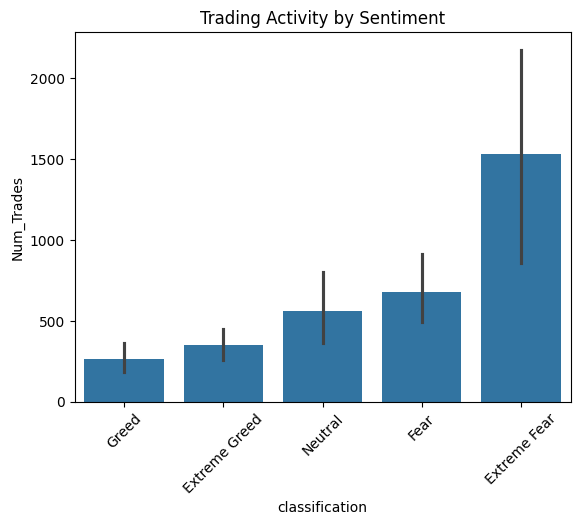

In [33]:
# Trade frequency
plt.figure()
sns.barplot(x='classification', y='Num_Trades', data=analysis_df)
plt.title('Trading Activity by Sentiment')
plt.xticks(rotation=45)
plt.show()

*Trading activity increases significantly during Fear and Extreme Fear market conditions. The number of trades is highest during Extreme Fear and lowest during Greed periods. This suggests that traders become more active during market downturns, possibly attempting to capitalize on volatility and price reversals.*

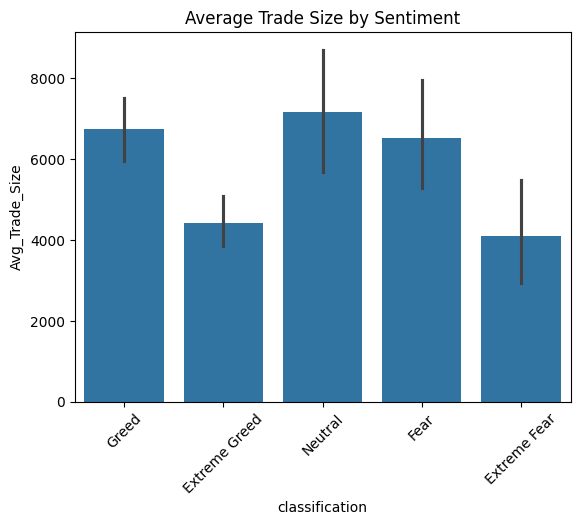

In [34]:
# Average trade size
plt.figure()
sns.barplot(x='classification', y='Avg_Trade_Size', data=analysis_df)
plt.title('Average Trade Size by Sentiment')
plt.xticks(rotation=45)
plt.show()

*Average trade size is highest during Neutral and Greed periods, while it decreases during Extreme Fear periods. This indicates that during Extreme Fear, traders execute more trades but with smaller position sizes, suggesting cautious trading behavior and risk management during highly volatile market conditions.*

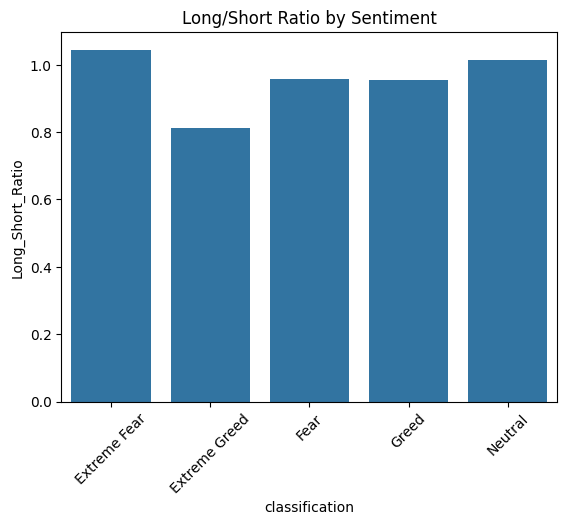

In [35]:
# Long/short ratio by sentiment
long_short_sentiment = merged.groupby(['classification','Side']).size().unstack()
long_short_sentiment['Long_Short_Ratio'] = long_short_sentiment['BUY'] / long_short_sentiment['SELL']
long_short_sentiment.reset_index(inplace=True)

plt.figure()
sns.barplot(x='classification', y='Long_Short_Ratio', data=long_short_sentiment)
plt.title('Long/Short Ratio by Sentiment')
plt.xticks(rotation=45)
plt.show()

| Sentiment     | Long/Short        |
| ------------- | ----------------- |
| Extreme Fear  | > 1 (More LONGS)  |
| Fear          | Slightly > 1      |
| Neutral       | > 1               |
| Greed         | ~ 1               |
| Extreme Greed | < 1 (More SHORTS) |


*The long/short ratio shows that traders tend to take more long positions during Fear and Extreme Fear periods, possibly expecting market rebounds. In contrast, during Extreme Greed periods, the long/short ratio decreases, indicating more short positions, possibly due to profit-taking or expectations of market corrections.*

***Thus we can conclude that, trader behavior changes significantly based on market sentiment. During Fear and Extreme Fear periods, traders increase their trading activity but reduce their average position size, indicating more cautious and short-term trading strategies. In contrast, during Greed periods, traders execute fewer trades but with larger position sizes, suggesting higher risk-taking per trade. Additionally, the long/short ratio indicates that traders tend to take more long positions during Fear periods, possibly anticipating price rebounds, while short positions increase during Extreme Greed periods, possibly due to profit-taking or expectations of market corrections.***

**High vs low frequency traders**

In [36]:
trader_activity = merged.groupby('Account')['Trade ID'].count().reset_index()
trader_activity.rename(columns={'Trade ID':'Total_Trades'}, inplace=True)

threshold = trader_activity['Total_Trades'].median()

trader_activity['Trader_Type'] = trader_activity['Total_Trades'].apply(
    lambda x: 'High Frequency' if x > threshold else 'Low Frequency'
)

print(trader_activity.head())

                                      Account  Total_Trades     Trader_Type
0  0x083384f897ee0f19899168e3b1bec365f52a9012          3818  High Frequency
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          7280  High Frequency
2  0x271b280974205ca63b716753467d5a371de622ab          3809  High Frequency
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4         13311  High Frequency
4  0x2c229d22b100a7beb69122eed721cee9b24011dd          3239   Low Frequency


In [37]:
freq_performance = pd.merge(trader_activity, daily_pnl, on='Account')

freq_summary = freq_performance.groupby('Trader_Type')['Daily_PnL'].mean().reset_index()
print(freq_summary)

      Trader_Type    Daily_PnL
0  High Frequency  4571.025650
1   Low Frequency  3901.353837


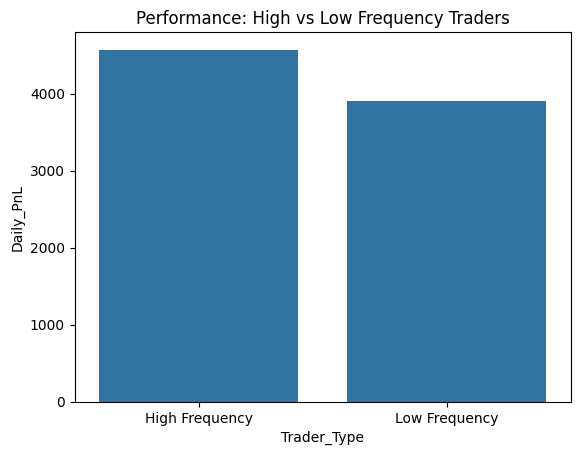

In [38]:
plt.figure()
sns.barplot(x='Trader_Type', y='Daily_PnL', data=freq_summary)
plt.title('Performance: High vs Low Frequency Traders')
plt.show()

*High-frequency traders generate higher average daily PnL compared to low-frequency traders. This suggests that more active traders are better able to take advantage of market opportunities and short-term price movements. However, higher trading frequency may also expose traders to higher transaction costs and risk, which should be managed carefully.*

**High vs Low Position Size Traders**

In [39]:
trader_size = merged.groupby('Account')['Size USD'].mean().reset_index()
trader_size.rename(columns={'Size USD':'Avg_Size'}, inplace=True)

threshold = trader_size['Avg_Size'].median()

trader_size['Size_Type'] = trader_size['Avg_Size'].apply(
    lambda x: 'High Size' if x > threshold else 'Low Size'
)

In [40]:
size_performance = pd.merge(trader_size, daily_pnl, on='Account')

size_summary = size_performance.groupby('Size_Type')['Daily_PnL'].mean().reset_index()
print(size_summary)

   Size_Type    Daily_PnL
0  High Size  6393.955383
1   Low Size  2795.118243


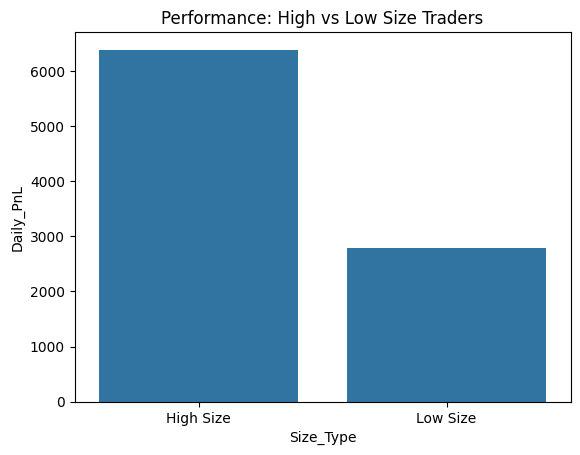

In [41]:
plt.figure()
sns.barplot(x='Size_Type', y='Daily_PnL', data=size_summary)
plt.title('Performance: High vs Low Size Traders')
plt.show()

*High-frequency traders generate higher average daily PnL compared to low-frequency traders. This suggests that more active traders are better able to take advantage of market opportunities and short-term price movements. However, higher trading frequency may also expose traders to higher transaction costs and risk, which should be managed carefully.*

**Consistent vs Inconsistent Traders**

In [42]:
trader_consistency = daily_pnl.groupby('Account')['Daily_PnL'].std().reset_index()
trader_consistency.rename(columns={'Daily_PnL':'PnL_std'}, inplace=True)

threshold = trader_consistency['PnL_std'].median()

trader_consistency['Consistency_Type'] = trader_consistency['PnL_std'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)

In [43]:
consistency_performance = pd.merge(trader_consistency, daily_pnl, on='Account')

consistency_summary = consistency_performance.groupby('Consistency_Type')['Daily_PnL'].mean().reset_index()
print(consistency_summary)

  Consistency_Type    Daily_PnL
0       Consistent  1187.255291
1     Inconsistent  9193.213020


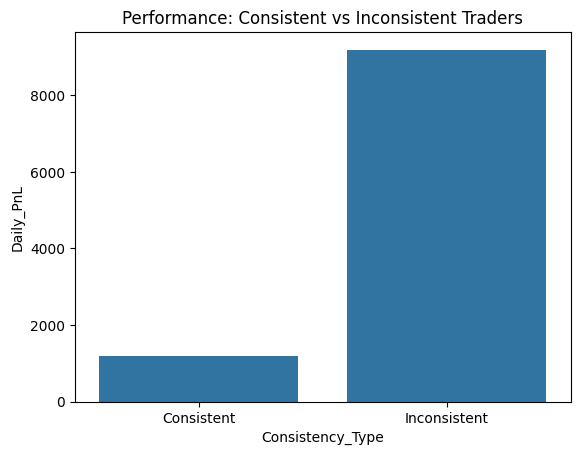

In [44]:
plt.figure()
sns.barplot(x='Consistency_Type', y='Daily_PnL', data=consistency_summary)
plt.title('Performance: Consistent vs Inconsistent Traders')
plt.show()

*Traders with larger average position sizes generate significantly higher profits compared to traders with smaller position sizes. This indicates that position sizing is a key driver of profitability. However, larger position sizes also increase risk exposure, meaning that risk management becomes more important for high-size traders.*

***Traders can be segmented into different behavioral groups based on trading frequency, position size, and return consistency. High-frequency traders tend to generate higher daily profits compared to low-frequency traders. Traders with larger position sizes generate significantly higher profits, indicating that position sizing is a major driver of performance. Additionally, inconsistent traders, who exhibit higher PnL volatility, achieve higher average profits compared to consistent traders, suggesting a clear risk-return tradeoff in trading behavior.***

In [45]:
strategy_table = summary_sentiment.copy()

# win rate
strategy_table = pd.merge(strategy_table, win_rate_sentiment, on='classification')

# drawdown proxy
strategy_table = pd.merge(strategy_table, drawdown_proxy_sentiment, on='classification')

# max loss
strategy_table = pd.merge(strategy_table, max_loss_sentiment, on='classification')

# long/short ratio
strategy_table = pd.merge(strategy_table, long_short_sentiment[['classification','Long_Short_Ratio']], on='classification')

print(strategy_table)

  classification  Daily_Total_PnL  Num_Traders  Avg_Trade_Size   Num_Trades  \
0   Extreme Fear     52793.589178    11.428571     4091.804366  1528.571429   
1  Extreme Greed     23817.292199     4.614035     4410.524482   350.807018   
2           Fear     36891.818040     6.923077     6524.294937   679.527473   
3          Greed     11140.566181     3.357513     6735.295813   260.637306   
4        Neutral     19297.323516     5.611940     7157.527121   562.477612   

        win  Drawdown_Proxy  Max_Daily_Loss  Long_Short_Ratio  
0  0.370607    29534.839183   -77308.420095          1.044912  
1  0.464943    27496.863832  -132271.000000          0.813532  
2  0.420768    31659.771538  -108604.496278          0.958913  
3  0.384828    30599.040173  -358963.139984          0.955261  
4  0.396991    17447.863645  -113601.020138          1.013464  


| Segment        | Behavior        | Performance | Risk   |
| -------------- | --------------- | ----------- | ------ |
| High Frequency | Many trades     | Higher PnL  | Medium |
| Low Frequency  | Few trades      | Lower PnL   | Low    |
| High Size      | Large positions | High PnL    | High   |
| Low Size       | Small positions | Low PnL     | Low    |
| Consistent     | Stable          | Lower PnL   | Low    |
| Inconsistent   | Volatile        | High PnL    | High   |


### **Key Insights**

**Insight 1: Traders Perform Better During Fear Than Greed**

Analysis of daily PnL and PnL per trader across different market sentiment regimes shows that median profitability is higher during Fear and Extreme Fear periods compared to Greed periods. While Extreme Greed periods show occasional large profits, the overall profitability is more volatile and inconsistent. This suggests that traders perform better during fearful market conditions, possibly due to more cautious trading, better entry points, and mean-reversion opportunities.

**Insight 2: Higher Win Rate Does Not Mean Higher Profit**

The win rate is highest during Extreme Greed periods; however, these periods do not correspond to the highest profitability. At the same time, Greed periods show the largest maximum daily losses. This indicates that traders may be making many small profitable trades during Greed markets but occasionally incur large losses that reduce overall profitability. This suggests poor risk management and overconfidence during Greed periods.

**Insight 3: Traders Trade More During Fear but With Smaller Positions**

Trading activity is significantly higher during Fear and Extreme Fear periods, while average trade size is smaller during Extreme Fear periods. This indicates that traders become more active during volatile markets but reduce their position size to manage risk. In contrast, during Greed periods, traders execute fewer trades but with larger position sizes, indicating higher risk per trade.

**Insight 4: Profitability Is Driven by Position Size and Risk-Taking**

Trader segmentation shows that high-frequency traders and high position-size traders generate higher profits. Additionally, inconsistent traders (higher PnL volatility) achieve significantly higher returns than consistent traders, indicating a strong risk-return tradeoff. Traders who take larger positions and higher risks tend to generate higher profits but also face higher volatility and drawdowns.

---

### **Strategy Recommendations**

**Strategy 1: Fear Market Strategy**

During Fear and Extreme Fear periods, traders should increase trading activity but maintain smaller position sizes. These periods show higher overall profitability and better trading opportunities, likely due to higher volatility and market overreactions.

**Strategy 2: Greed Market Strategy**

During Greed and Extreme Greed periods, traders should reduce position sizes and avoid overtrading. These periods show higher win rates but lower overall profitability and larger maximum losses, indicating poor risk-reward conditions.

**Strategy 3: Risk Management Strategy**

Position sizing and risk management are the most important drivers of profitability. Traders using larger position sizes generate higher profits but also face higher volatility. Therefore, traders should adjust position sizes based on market sentiment — smaller positions during Greed and larger but controlled positions during Fear.

---

### **Conclusion**

This analysis demonstrates that market sentiment significantly influences trader performance and behavior. Traders tend to trade more frequently during Fear periods and take larger position sizes during Greed periods. However, profitability is higher during Fear periods, while Greed periods are associated with higher risk and larger losses. Trader segmentation further shows that profitability is strongly linked to position sizing, trading frequency, and risk-taking behavior. These findings suggest that sentiment-aware trading strategies and proper risk management can significantly improve trading performance.

# **Bonus**

**Clustering traders into behavioral archetypes**

In [46]:
from sklearn.cluster import KMeans

In [47]:
trader_features = merged.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'Trade ID':'count',
    'Fee':'mean'
}).reset_index()

trader_features.rename(columns={
    'Closed PnL':'Avg_PnL',
    'Size USD':'Avg_Size',
    'Trade ID':'Num_Trades',
    'Fee':'Avg_Fee'
}, inplace=True)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['Cluster'] = kmeans.fit_predict(trader_features[['Avg_PnL','Avg_Size','Num_Trades','Avg_Fee']])

print(trader_features.head())

                                      Account     Avg_PnL      Avg_Size  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782   

   Num_Trades   Avg_Fee  Cluster  
0        3818  1.939579        0  
1        7280  0.374978        2  
2        3809  2.436593        0  
3       13311  0.166657        2  
4        3239  0.959616        0  


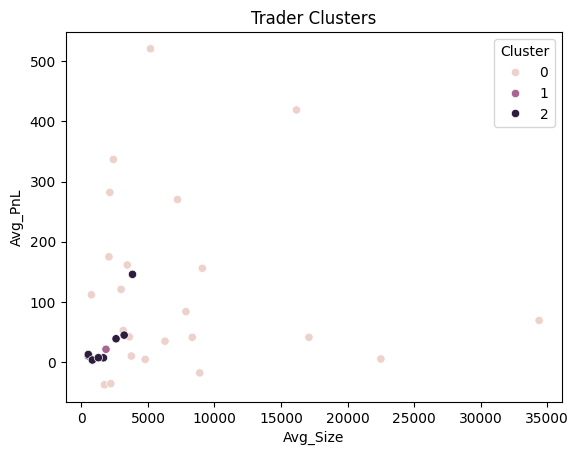

In [48]:
plt.figure()
sns.scatterplot(x='Avg_Size', y='Avg_PnL', hue='Cluster', data=trader_features)
plt.title('Trader Clusters')
plt.show()

**Simple predictive model**

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [50]:
ml_df = analysis_df.copy()

ml_df = ml_df.sort_values('Date')

ml_df['Next_Day_PnL'] = ml_df['Daily_Total_PnL'].shift(-1)

ml_df['Target'] = ml_df['Next_Day_PnL'].apply(lambda x: 1 if x > 0 else 0)

ml_df = ml_df.dropna()

In [51]:
ml_df['Sentiment'] = ml_df['classification'].map({
    'Extreme Fear':0,
    'Fear':1,
    'Neutral':2,
    'Greed':3,
    'Extreme Greed':4
})

In [52]:
features = ['Sentiment','Num_Traders','Avg_Trade_Size','Num_Trades']
X = ml_df[features]
y = ml_df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.90      1.00      0.95        86

    accuracy                           0.90        96
   macro avg       0.45      0.50      0.47        96
weighted avg       0.80      0.90      0.85        96



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

feature_importance.sort_values(by='Importance', ascending=False, inplace=True)
print(feature_importance)

          Feature  Importance
2  Avg_Trade_Size    0.419296
3      Num_Trades    0.357203
0       Sentiment    0.112925
1     Num_Traders    0.110575


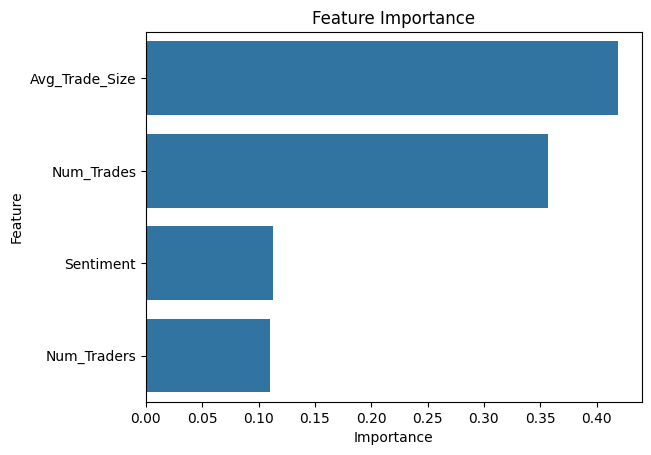

In [54]:
plt.figure()
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

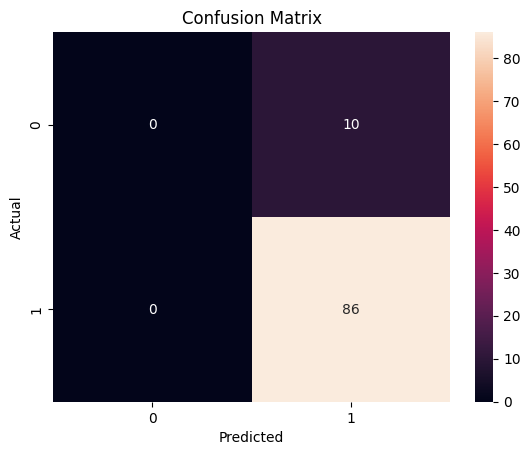

In [55]:
cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**A lightweight dashboard (Streamlit)**

In [56]:
!pip install streamlit
import streamlit as st

2026-03-26 16:16:11.703 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 16:16:12.115 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-26 16:16:12.118 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 16:16:12.121 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 16:16:12.124 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 16:16:12.125 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 16:16:12.126 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 16:16:12.249 Thread 'MainThread': mi

DeltaGenerator()

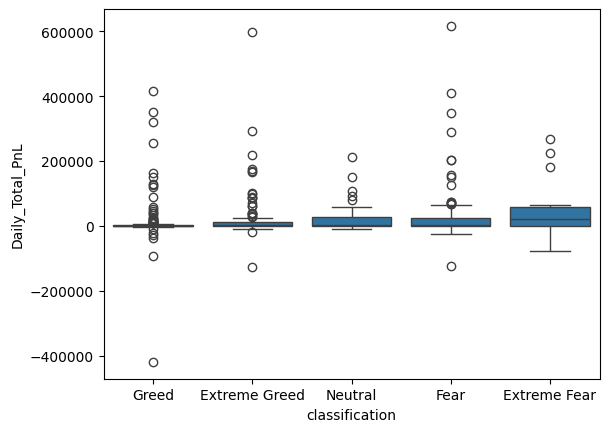

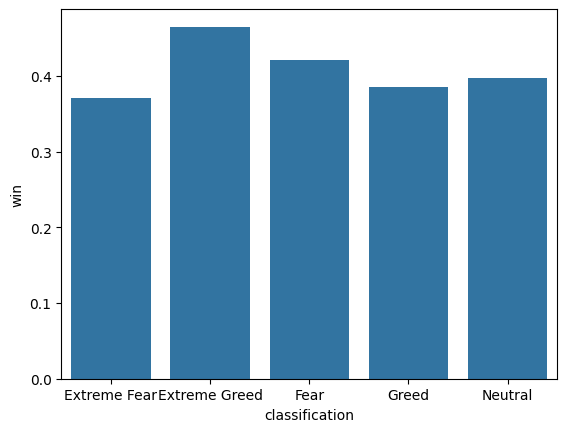

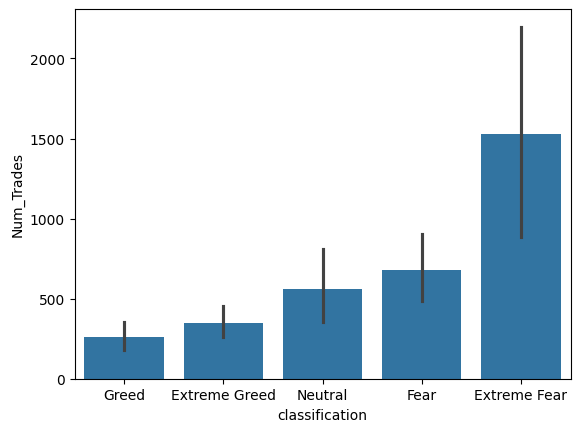

In [57]:
st.title("Trader Performance vs Market Sentiment")

st.subheader("PnL by Sentiment")
fig, ax = plt.subplots()
sns.boxplot(x='classification', y='Daily_Total_PnL', data=analysis_df, ax=ax)
st.pyplot(fig)

st.subheader("Win Rate by Sentiment")
fig, ax = plt.subplots()
sns.barplot(x='classification', y='win', data=win_rate_sentiment, ax=ax)
st.pyplot(fig)

st.subheader("Trading Activity")
fig, ax = plt.subplots()
sns.barplot(x='classification', y='Num_Trades', data=analysis_df, ax=ax)
st.pyplot(fig)